In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import FortranFile as FF

In [ ]:
#read points.dat with FF
with FF('points.dat', 'r') as f:
    n = f.read_ints('i4')[0]
    x = f.read_reals('f4')
    y = f.read_reals('f4')
    z = f.read_reals('f4')

print('N', n)

1000000
1000000 1000000 1000000


In [75]:
#read groups.dat with FF
with FF('groups.dat', 'r') as f:
    Ngroup = f.read_ints('i4')[0]
    NfriendGroup = f.read_ints('i4')
    groups = []
    for i in range(Ngroup):
        groups.append(f.read_ints('i4'))

print("Ngroup:", Ngroup)
print(f"% in groups: {sum(NfriendGroup)/len(x)*100:.2f}")
print("NfriendGroup:", NfriendGroup)

Ngroup: 28359
% in groups: 61.68
NfriendGroup: [1823    2    3 ...    2    2    2]


In [76]:
# Clean groups, keep only largest
Nmin = 200
groups = [g for g, n in zip(groups, NfriendGroup) if n >= Nmin]
NfriendGroup = [n for n in NfriendGroup if n >= Nmin]
Ngroup = len(groups)

print("Filtered Ngroup:", Ngroup)

#index to 0->Ngroup-1
for i in range(Ngroup):
    groups[i] = [p - 1 for p in groups[i]]

    

Filtered Ngroup: 300


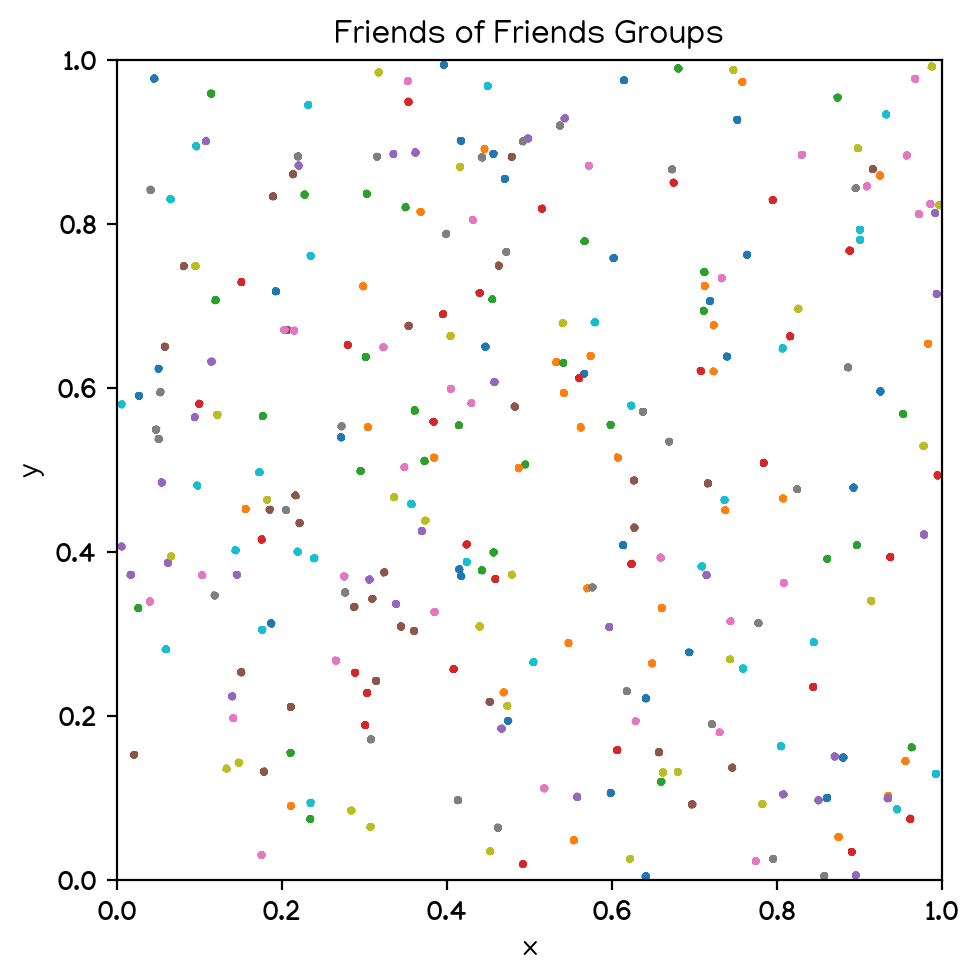

In [77]:
# Plot (X,Y)
fig, ax = plt.subplots(figsize=(5,5), dpi = 200)
for i in range(Ngroup):
    ax.scatter(x[groups[i]], y[groups[i]], s=1, marker = '.', alpha = 0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Friends of Friends Groups')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('fof_groups.png', dpi=300)
plt.show()


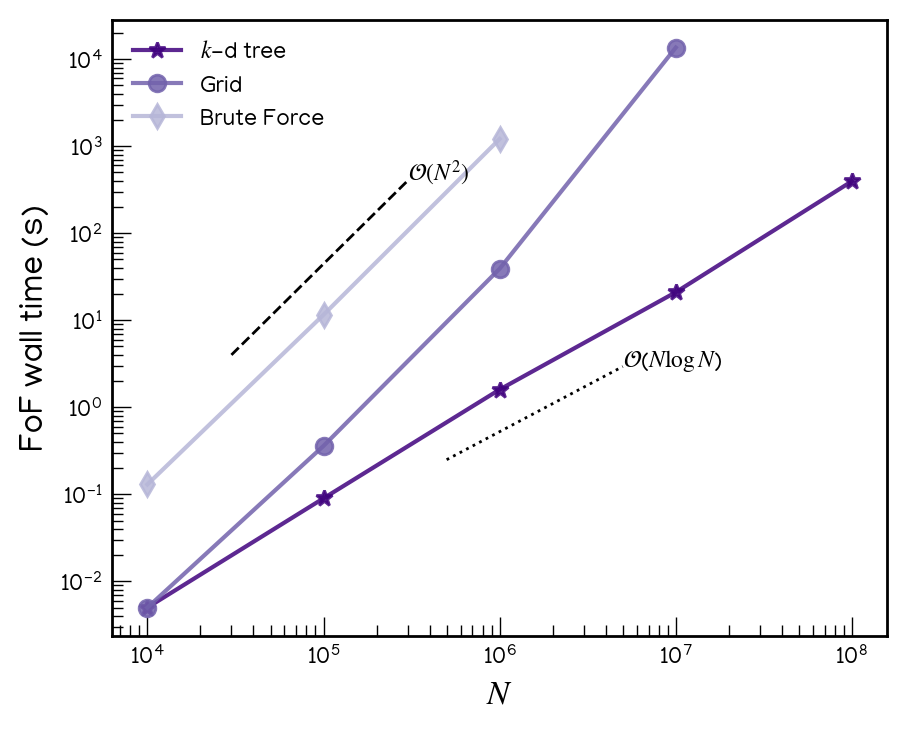

In [9]:
# FoF benchmark with different methods
s = 6
alpha = 0.85
fontsize = 8.5
spines_width = 1.
majTickLength = 7
minTickLength = 4
linewidth = 1.5

plt.rcParams["font.family"] = "Manjari"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["mathtext.bf"] = ""

#color from cmap
cmap = plt.get_cmap('Purples')
c3 = cmap(0.4)
c2 = cmap(0.7)
c1 = cmap(0.99)

N = [1e4, 1e5, 1e6, 1e7, 1e8]
time_kd = [0.005, 0.09, 1.6, 21, 396]
time_grid = [0.005, 0.36, 39.1, 13579]
time_brute = [0.13, 11.56, 1210]

plt.figure(figsize=(5,4), dpi = 200)
plt.plot(N, time_kd, marker='*', markersize=s, linewidth=linewidth, label='$k$-d tree', alpha=alpha, color = c1)
plt.plot(N[:4], time_grid, marker='o', markersize=s, linewidth=linewidth, label='Grid', alpha=alpha, color = c2)
plt.plot(N[:3], time_brute, marker='d', markersize=s, linewidth=linewidth, label='Brute Force', alpha=alpha, color = c3)
plt.ylabel('FoF wall time (s)', fontsize=12)
plt.xlabel('$N$', fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.legend(frameon=False, fontsize=fontsize, loc='upper left')

#thicker axis lines
plt.gca().spines['top'].set_linewidth(spines_width)
plt.gca().spines['right'].set_linewidth(spines_width)
plt.gca().spines['bottom'].set_linewidth(spines_width)
plt.gca().spines['left'].set_linewidth(spines_width)

#Ticks direction in, longer
plt.minorticks_on()
plt.tick_params(axis='both', which='major', length=majTickLength, width=0.5*spines_width, direction='in', labelsize=fontsize)
plt.tick_params(axis='both', which='minor', length=minTickLength, width=0.5*spines_width, direction='in')

#O(N^2) scaling and # O(N log N) scaling
N_ref_NLOGN = np.array([5e5,5e6])
N_ref_N2 = np.array([3e4,3e5])
t0_NLOGN = 0.25
t0_N2 = 4
N0_NLOGN = N_ref_NLOGN[0]
N0_N2 = N_ref_N2[0]
NLOGN_scaling_ref = (t0_NLOGN / (N0_NLOGN * np.log(N0_NLOGN))) * N_ref_NLOGN * np.log(N_ref_NLOGN)
N2_scaling_ref = (t0_N2 / (N0_N2**2)) * N_ref_N2**2
plt.loglog(N_ref_NLOGN, NLOGN_scaling_ref, color='black', linestyle='dotted', linewidth = 1)
plt.text(1.*N_ref_NLOGN[-1], 1.*NLOGN_scaling_ref[-1], '$\mathcal{O}$($N \log N$)', fontsize=fontsize, color='black')
plt.loglog(N_ref_N2, N2_scaling_ref, color='black', linestyle='dashed', linewidth = 1)
plt.text(1.*N_ref_N2[-1], 1.*N2_scaling_ref[-1], '$\mathcal{O}(N^2)$', fontsize=fontsize, color='black')

plt.savefig('fof_benchmark.pdf')